# Sprint 4: Exploratory Data Analysis (EDA)

## Project
InsightForge – Retail Intelligence Platform

## Objective
Analyze the cleaned Olist E-commerce dataset to uncover business insights and answer key business questions.

## Author
Gurleen Kaur Sawhney

## Date
August 2026

## Goals

- Analyze sales trends
- Analyze customer behavior
- Analyze product performance
- Analyze payment patterns
- Analyze delivery performance
- Analyze customer reviews
- Generate business insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
CLEAN_PATH = Path("../data/cleaned")

orders = pd.read_csv(
    CLEAN_PATH / "orders_cleaned.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

customers = pd.read_csv(CLEAN_PATH / "customers_cleaned.csv")

order_items = pd.read_csv(CLEAN_PATH / "order_items_cleaned.csv")

products = pd.read_csv(CLEAN_PATH / "products_cleaned.csv")

payments = pd.read_csv(CLEAN_PATH / "payments_cleaned.csv")

reviews = pd.read_csv(CLEAN_PATH / "reviews_cleaned.csv")

sellers = pd.read_csv(CLEAN_PATH / "sellers_cleaned.csv")

geolocation = pd.read_csv(CLEAN_PATH / "geolocation_cleaned.csv")

category_translation = pd.read_csv(
    CLEAN_PATH / "category_translation_cleaned.csv"
)

In [3]:
print("Datasets Loaded Successfully\n")

print(f"Orders: {orders.shape}")
print(f"Customers: {customers.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Products: {products.shape}")
print(f"Payments: {payments.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Sellers: {sellers.shape}")

Datasets Loaded Successfully

Orders: (99441, 10)
Customers: (99441, 5)
Order Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
Sellers: (3095, 4)


In [4]:
# Revenue per Order

orders_with_revenue = (
    order_items
    .groupby("order_id")["price"]
    .sum()
    .reset_index(name="order_revenue")
)

orders_with_revenue = orders.merge(
    orders_with_revenue,
    on="order_id",
    how="left"
)

orders_with_revenue.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,order_month,order_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017-10,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,2018-07,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,2018-08,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,2017-11,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,2018-02,19.90


In [5]:
# Create Year-Month column

orders_with_revenue["order_month"] = (
    orders_with_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
)

# Monthly Revenue

monthly_revenue = (
    orders_with_revenue
    .groupby("order_month")["order_revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,order_month,order_revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


In [6]:
monthly_revenue["order_month"] = monthly_revenue["order_month"].astype(str)

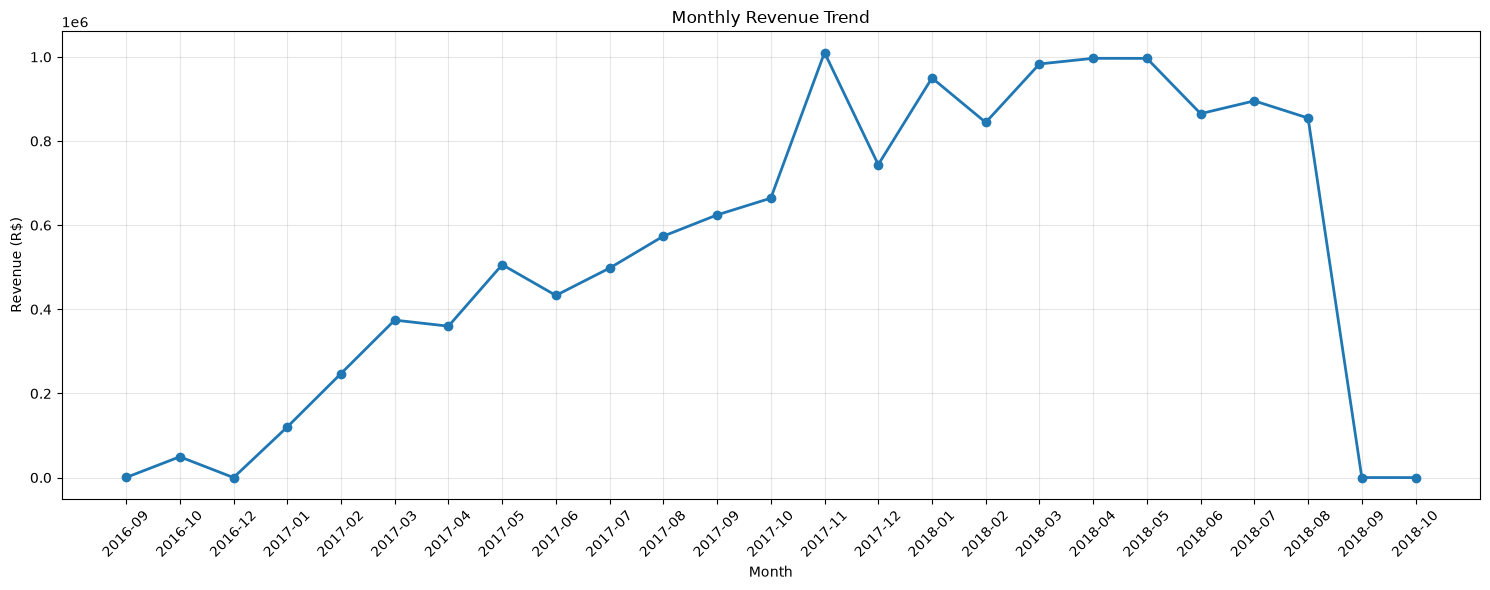

In [7]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["order_revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [8]:
print("=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

print(f"Total Revenue : R$ {orders_with_revenue['order_revenue'].sum():,.2f}")

print(f"Average Monthly Revenue : R$ {monthly_revenue['order_revenue'].mean():,.2f}")

print(f"Highest Revenue Month : {monthly_revenue.loc[monthly_revenue['order_revenue'].idxmax(),'order_month']}")

print(f"Lowest Revenue Month : {monthly_revenue.loc[monthly_revenue['order_revenue'].idxmin(),'order_month']}")

EXECUTIVE SUMMARY
Total Revenue : R$ 13,591,643.70
Average Monthly Revenue : R$ 543,665.75
Highest Revenue Month : 2017-11
Lowest Revenue Month : 2018-10


In [9]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [10]:
product_sales = (
    order_items.merge(
        products,
        on="product_id",
        how="left"
    )
)

product_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [11]:
category_revenue = (
    product_sales
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.head(10)

,product_category_name_english,price
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


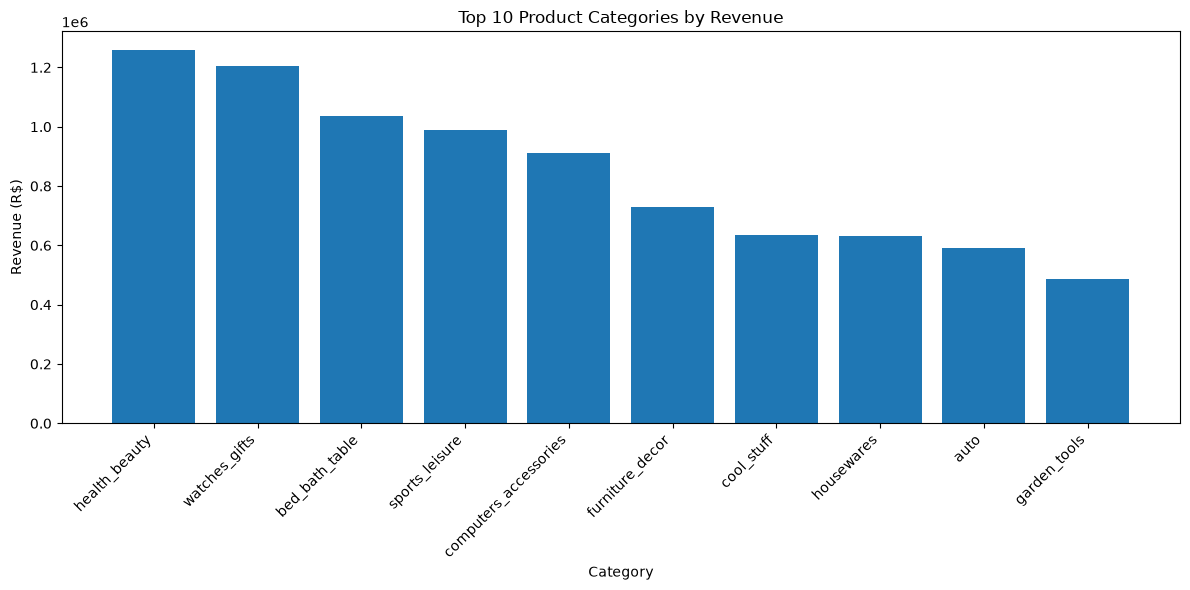

In [12]:
top10 = category_revenue.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["product_category_name_english"],
    top10["price"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue (R$)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [13]:
total_revenue = order_items["price"].sum()
print(f"Total Revenue: R$ {total_revenue:,.2f}")

Total Revenue: R$ 13,591,643.70


In [14]:
total_orders = orders["order_id"].nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 99,441


In [15]:
total_customers = customers["customer_unique_id"].nunique()
print(f"Total Customers: {total_customers:,}")

Total Customers: 96,096


In [16]:
average_order_value = total_revenue / total_orders

print(f"Average Order Value: R$ {average_order_value:,.2f}")

Average Order Value: R$ 136.68


In [17]:
average_review_score = reviews["review_score"].mean()

print(f"Average Review Score: {average_review_score:.2f}")

Average Review Score: 4.09


In [18]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [19]:
average_delivery = orders["delivery_days"].mean()

print(f"Average Delivery Time: {average_delivery:.1f} days")

Average Delivery Time: 12.1 days


In [20]:
executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Average Review Score",
        "Average Delivery Time"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        average_order_value,
        average_review_score,
        average_delivery
    ]
})

executive_kpis

,KPI,Value
0,Total Revenue,1.359164e+07
1,Total Orders,9.944100e+04
2,Total Customers,9.609600e+04
3,Average Order Value,1.366805e+02
4,Average Review Score,4.086421e+00
5,Average Delivery Time,1.209409e+01


In [21]:
# Count orders placed by each customer

customer_orders = (
    orders
    .groupby("customer_id")["order_id"]
    .count()
    .reset_index(name="number_of_orders")
)

customer_orders.head()

,customer_id,number_of_orders
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


In [22]:
repeat_customers = customer_orders[
    customer_orders["number_of_orders"] > 1
]

repeat_customers.head()

,customer_id,number_of_orders


In [23]:
print(f"Repeat Customers: {len(repeat_customers):,}")

Repeat Customers: 0


In [24]:
print(f"Repeat Customers: {len(repeat_customers):,}")

Repeat Customers: 0


In [25]:
repeat_customer_rate = (
    len(repeat_customers)
    / len(customer_orders)
) * 100

print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")

Repeat Customer Rate: 0.00%


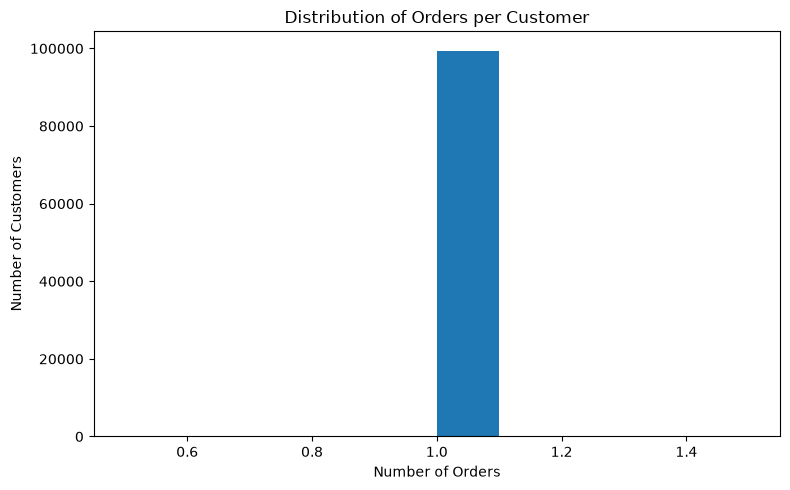

In [26]:
plt.figure(figsize=(8,5))

plt.hist(
    customer_orders["number_of_orders"],
    bins=10
)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()